2.7.1+cu128
True
NVIDIA GeForce RTX 5060 Laptop GPU


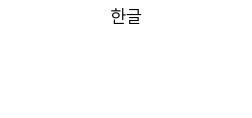

In [1]:
import torch
import matplotlib.pyplot as plt
from matplotlib import rcParams
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

print(torch.__version__)
print(torch.cuda.is_available())     
print(torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize = (3, 1))
plt.title("한글")
plt.axis("off")
plt.show()

In [2]:
review = "현실과 구분 불가능한 cg. 시각적 즐거움은 최고! 더불어 ost는 더더욱 최고!!"
tokenized = review.split()
print(tokenized)

['현실과', '구분', '불가능한', 'cg.', '시각적', '즐거움은', '최고!', '더불어', 'ost는', '더더욱', '최고!!']


In [3]:
review = "현실과 구분 불가능한 cg. 시각적 즐거움은 최고! 더불어 ost는 더더욱 최고!!"
tokenized = list(review)
print(tokenized)

['현', '실', '과', ' ', '구', '분', ' ', '불', '가', '능', '한', ' ', 'c', 'g', '.', ' ', '시', '각', '적', ' ', '즐', '거', '움', '은', ' ', '최', '고', '!', ' ', '더', '불', '어', ' ', 'o', 's', 't', '는', ' ', '더', '더', '욱', ' ', '최', '고', '!', '!']


In [4]:
from jamo import h2j, j2hcj
review = "현실과 구분 불가능한 cg. 시각적 즐거움은 최고! 더불어 ost는 더더욱 최고!!"
decomposed = j2hcj(h2j(review))
tokenized = list(decomposed)
print(tokenized)

['ㅎ', 'ㅕ', 'ㄴ', 'ㅅ', 'ㅣ', 'ㄹ', 'ㄱ', 'ㅘ', ' ', 'ㄱ', 'ㅜ', 'ㅂ', 'ㅜ', 'ㄴ', ' ', 'ㅂ', 'ㅜ', 'ㄹ', 'ㄱ', 'ㅏ', 'ㄴ', 'ㅡ', 'ㅇ', 'ㅎ', 'ㅏ', 'ㄴ', ' ', 'c', 'g', '.', ' ', 'ㅅ', 'ㅣ', 'ㄱ', 'ㅏ', 'ㄱ', 'ㅈ', 'ㅓ', 'ㄱ', ' ', 'ㅈ', 'ㅡ', 'ㄹ', 'ㄱ', 'ㅓ', 'ㅇ', 'ㅜ', 'ㅁ', 'ㅇ', 'ㅡ', 'ㄴ', ' ', 'ㅊ', 'ㅚ', 'ㄱ', 'ㅗ', '!', ' ', 'ㄷ', 'ㅓ', 'ㅂ', 'ㅜ', 'ㄹ', 'ㅇ', 'ㅓ', ' ', 'o', 's', 't', 'ㄴ', 'ㅡ', 'ㄴ', ' ', 'ㄷ', 'ㅓ', 'ㄷ', 'ㅓ', 'ㅇ', 'ㅜ', 'ㄱ', ' ', 'ㅊ', 'ㅚ', 'ㄱ', 'ㅗ', '!', '!']


In [5]:
# 한글전용처리 konlpy 사용해서 토큰화

from konlpy.tag import Okt

okt = Okt()

sentence = "무엇이든 상상할 수 있는 사람은 무엇이든 만들어 낼 수 있다."

# 명사
nouns = okt.nouns(sentence)
# 구
phrases = okt.phrases(sentence)
# 형태소
morphs = okt.morphs(sentence)
# 품사
pos = okt.pos(sentence)

print(nouns)
print(phrases)
print(morphs)
print(pos)

['무엇', '상상', '수', '사람', '무엇', '낼', '수']
['무엇', '상상', '상상할 수', '상상할 수 있는 사람', '사람']
['무엇', '이든', '상상', '할', '수', '있는', '사람', '은', '무엇', '이든', '만들어', '낼', '수', '있다', '.']
[('무엇', 'Noun'), ('이든', 'Josa'), ('상상', 'Noun'), ('할', 'Verb'), ('수', 'Noun'), ('있는', 'Adjective'), ('사람', 'Noun'), ('은', 'Josa'), ('무엇', 'Noun'), ('이든', 'Josa'), ('만들어', 'Verb'), ('낼', 'Noun'), ('수', 'Noun'), ('있다', 'Adjective'), ('.', 'Punctuation')]


In [6]:
from konlpy.tag import Kkma

kkma = Kkma()

sentence = "무엇이든 상상할 수 있는 사람은 무엇이든 만들어 낼 수 있다."

# 명사
nouns = kkma.nouns(sentence)
# 구
phrases = kkma.sentences(sentence)
# 형태소
morphs = kkma.morphs(sentence)
# 품사
pos = kkma.pos(sentence)

print(nouns)
print(phrases)
print(morphs)
print(pos)

['무엇', '상상', '수', '사람', '무엇']
['무엇이든 상상할 수 있는 사람은 무엇이든 만들어 낼 수 있다.']
['무엇', '이', '든', '상상', '하', 'ㄹ', '수', '있', '는', '사람', '은', '무엇', '이', '든', '만들', '어', '내', 'ㄹ', '수', '있', '다', '.']
[('무엇', 'NNG'), ('이', 'VCP'), ('든', 'ECE'), ('상상', 'NNG'), ('하', 'XSV'), ('ㄹ', 'ETD'), ('수', 'NNB'), ('있', 'VV'), ('는', 'ETD'), ('사람', 'NNG'), ('은', 'JX'), ('무엇', 'NP'), ('이', 'VCP'), ('든', 'ECE'), ('만들', 'VV'), ('어', 'ECD'), ('내', 'VXV'), ('ㄹ', 'ETD'), ('수', 'NNB'), ('있', 'VV'), ('다', 'EFN'), ('.', 'SF')]


In [7]:
import nltk

nltk.download("punkt")
nltk.download("averaged_perceptron_tagger")
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\KDT-17\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\KDT-17\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KDT-17\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\KDT-17\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [8]:
from nltk import tokenize

sentence = "Those who can imagine anything, can create the impossible"

word_tokens = tokenize.word_tokenize(sentence)
sent_tokens = tokenize.sent_tokenize(sentence)

print(word_tokens)
print(sent_tokens)

['Those', 'who', 'can', 'imagine', 'anything', ',', 'can', 'create', 'the', 'impossible']
['Those who can imagine anything, can create the impossible']


In [9]:
from nltk import tag
from nltk import tokenize

sentence = "Those who can imagine anything, can create the impossible"

word_tokens = tokenize.word_tokenize(sentence)
pos = tag.pos_tag(word_tokens)

print(pos)

[('Those', 'DT'), ('who', 'WP'), ('can', 'MD'), ('imagine', 'VB'), ('anything', 'NN'), (',', ','), ('can', 'MD'), ('create', 'VB'), ('the', 'DT'), ('impossible', 'JJ')]


In [10]:
import spacy

nlp = spacy.load("en_core_web_sm")
sentence = "Those who can imagine anything, can create the impossible"
doc = nlp(sentence)

for token in doc:
    print(token.pos_, token.tag_, token.text)

PRON DT Those
PRON WP who
AUX MD can
VERB VB imagine
PRON NN anything
PUNCT , ,
AUX MD can
VERB VB create
DET DT the
ADJ JJ impossible


In [13]:
from Korpora import Korpora

corpus = Korpora.load('korean_petitions')
dataset = corpus.train
petition = dataset[0]

print(petition.begin)
print(petition.end)
print(petition.num_agree)
print(petition.category)
print(petition.title)
print(petition.text[:30])


    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : Hyunjoong Kim lovit@github
    Repository : https://github.com/lovit/petitions_archive
    References :

    청와대 국민청원 게시판의 데이터를 월별로 수집한 것입니다.
    청원은 게시판에 글을 올린 뒤, 한달 간 청원이 진행됩니다.
    수집되는 데이터는 청원종료가 된 이후의 데이터이며, 청원 내 댓글은 수집되지 않습니다.
    단 청원의 동의 개수는 수집됩니다.
    자세한 내용은 위의 repository를 참고하세요.

    # License
    CC0 1.0 Universal (CC0 1.0) Public Domain Dedication
    Details in https://creativecommons.org/publicdomain/zero/1.0/



[korean_petitions] download petitions_2017-08: 1.84MB [00:00, 10.2MB/s]                            
[korean_petitions] download petitions_2017-09: 20.4MB [00:00, 52.6MB/s]                            
[korean_petitions] download petitions_2017-10: 12.0MB [00:00, 53.9MB/s]                            
[korean_petitions] download petitions_2017-11: 28.4MB [00:00, 68.0MB/s]                            
[korean_petitions] download petitions_2017-12: 29.0MB [00:00, 72.3MB/s]                            
[korean_petitions] download petitions_2018-01: 43.9MB [00:00, 72.2MB/s]                            
[korean_petitions] download petitions_2018-02: 33.8MB [00:00, 77.6MB/s]                            
[korean_petitions] download petitions_2018-03: 34.3MB [00:00, 71.9MB/s]                            
[korean_petitions] download petitions_2018-04: 35.5MB [00:00, 65.6MB/s]                            
[korean_petitions] download petitions_2018-05: 37.5MB [00:00, 68.2MB/s]                            


2017-08-25
2017-09-24
88
육아/교육
학교는 인력센터, 취업센터가 아닙니다. 정말 간곡히 부탁드립니다.
안녕하세요. 현재 사대, 교대 등 교원양성학교들의 예비


In [ ]:
# trainset 생성
petitions = corpus.get_all_texts()
with open("data/corpus.txt", "w", encoding = "utf-8") as f:
    for petition in petitions:
        f.write(petition + "\n")

In [16]:
from sentencepiece import SentencePieceTrainer

SentencePieceTrainer.Train("--input=data/corpus.txt "
                           "--model_prefix=models/petition_bpe "
                           "--vocab_size=8000 "
                           "--model_type=bpe")

In [17]:
from sentencepiece import SentencePieceProcessor

tokenizer = SentencePieceProcessor()
tokenizer.load("models/petition_bpe.model")

sentence = "안녕하세요. 토크나이저가 잘 학습되었군요!."
sentences = ["이렇게 입력값을 리스트로 받아서", "쉽게 토크나이저를 사용할 수 있답니다."]

tokenized_sentence = tokenizer.encode_as_pieces(sentence)
tokenized_sentences = tokenizer.encode_as_pieces(sentences)
print(tokenized_sentence)
print(tokenized_sentences)

encoded_sentence = tokenizer.encode_as_ids(sentence)
encoded_sentences = tokenizer.encode_as_ids(sentences)
print(encoded_sentence)
print(encoded_sentences)

decoded_ids = tokenizer.decode_ids(encoded_sentences)
decoded_pieces = tokenizer.decode_pieces(tokenized_sentences)
print(decoded_ids)
print(decoded_pieces)

['▁안녕하세요', '.', '▁토', '크', '나', '이', '저', '가', '▁잘', '▁학', '습', '되었', '군요', '!', '.']
[['▁이렇게', '▁입', '력', '값을', '▁리', '스트', '로', '▁받아서'], ['▁쉽게', '▁토', '크', '나', '이', '저', '를', '▁사용할', '▁수', '▁있', '답니다', '.']]
[667, 6515, 994, 6880, 6544, 6513, 6590, 6523, 161, 110, 6554, 872, 787, 6648, 6515]
[[372, 182, 6677, 4433, 1772, 1613, 6527, 4162], [1681, 994, 6880, 6544, 6513, 6590, 6536, 5852, 19, 5, 2639, 6515]]
['이렇게 입력값을 리스트로 받아서', '쉽게 토크나이저를 사용할 수 있답니다.']
['이렇게 입력값을 리스트로 받아서', '쉽게 토크나이저를 사용할 수 있답니다.']


In [18]:
vocab = {idx: tokenizer.id_to_piece(idx) for idx in range(tokenizer.get_piece_size())}
print(list(vocab.items())[:5])
print(len(vocab))

[(0, '<unk>'), (1, '<s>'), (2, '</s>'), (3, '니다'), (4, '▁이')]
8000


In [19]:
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers.normalizers import Sequence, NFD, Lowercase
from tokenizers.pre_tokenizers import Whitespace

tokenizer = Tokenizer(WordPiece())
tokenizer.normalizer = Sequence([NFD(), Lowercase()])
tokenizer.pre_tokenizer = Whitespace()

# tokenizer.train(["data/corpus.txt"])
# tokenizer.save("models/petition_wordpiece.json")

from itertools import islice

with open("data/corpus.txt", encoding = "utf-8") as f:
    tokenizer.train_from_iterator(islice(f, 100_000))
tokenizer.save("models/petition_wordpiece.json")

In [20]:
from tokenizers import Tokenizer
from tokenizers.decoders import WordPiece as WordPieceDecoder

tokenizer = Tokenizer.from_file("models/petition_wordpiece.json")
tokenizer.decoder = WordPieceDecoder()

sentence = "안녕하세요. 토크나이저가 잘 학습되었군요!."
sentences = ["이렇게 입력값을 리스트로 받아서", "쉽게 토크나이저를 사용할 수 있답니다."]

encoded_sentence = tokenizer.encode(sentence)
encoded_sentences = tokenizer.encode_batch(sentences)

print(type(encoded_sentence))
print(type(encoded_sentence.tokens))
print([enc.tokens for enc in encoded_sentences])
print(encoded_sentence.ids)
print([enc.ids for enc in encoded_sentences])
print(tokenizer.decode(encoded_sentence.ids))

<class 'tokenizers.Encoding'>
<class 'list'>
[['이렇게', '입력', '##값을', '리', '##스트', '##로', '받아서'], ['쉽게', '토', '##크', '##나이', '##저를', '사용할', '수', '있답니다', '.']]
[4841, 13, 4941, 4569, 9429, 3714, 3669, 4046, 10271, 4908, 5069, 0, 2130]
[[4368, 14815, 9716, 5282, 6084, 3674, 9573], [5918, 4941, 4569, 9429, 23321, 9266, 3738, 29378, 13]]
안녕하세요. 토크나이저가 잘 학습되었군요!.
